# 🧹 Notebook 02 — Tiền xử lý NLP

**Mục tiêu:**
- Làm sạch văn bản tiếng Việt (HTML, emoji, ký tự đặc biệt)
- Chuẩn hóa teencode / từ viết tắt
- Tách từ (Tokenization) với `underthesea`
- Loại bỏ Stopwords tiếng Việt
- POS Tagging — giữ lại Noun, Verb, Adjective
- TF-IDF Vectorization với N-gram (1,3)
- Lưu vectorizer và processed data

**Đầu vào:** `datas/processed/merged_sentiment.csv`  
**Đầu ra:** `datas/processed/processed_reviews.csv`, `datas/processed/tfidf_vectorizer.pkl`

## 1. Import thư viện

In [28]:
import pandas as pd
import numpy as np
import re
import unicodedata
import joblib
import warnings
import sys
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

try:
    from underthesea import word_tokenize, pos_tag
    UNDERTHESEA_AVAILABLE = True
    print('✅ underthesea sẵn sàng')
except ImportError:
    UNDERTHESEA_AVAILABLE = False
    print('⚠️  underthesea chưa được cài đặt. Dùng tokenizer đơn giản.')

warnings.filterwarnings('ignore')
tqdm.pandas()

ROOT_DIR = Path('..').resolve()
PROCESSED_DIR = ROOT_DIR / 'datas' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT_DIR))
from src.utils.text_preprocess import load_stopwords, preprocess_text

print(f'✅ ROOT_DIR: {ROOT_DIR}')

✅ underthesea sẵn sàng
✅ ROOT_DIR: F:\codingSpace\Asm\ecom_rcm_1


## 2. Tải dữ liệu đã gộp

In [29]:
df = pd.read_csv(PROCESSED_DIR / 'merged_sentiment.csv')
print(f'✅ Đã tải: {df.shape}')
print(f'Phân phối nhãn: {df["label"].value_counts().to_dict()}')
display(df.head(3))

✅ Đã tải: (32170, 3)
Phân phối nhãn: {1: 19873, 0: 12297}


,review_text,label,source
0,Tốt Gói Hàng đẹp Shop phục vụ rất tốt.,1,tiki_sentiment
1,Mk nhận đk hàng rồi đẹp lắm cảm ơn shop nhé 😊.,1,tiki_sentiment
2,Bố t thích áo này lắm y.,1,tiki_sentiment


## 3. Từ điển chuẩn hóa Teencode / Viết tắt

In [30]:
# Load stopwords tu file trong repo mau (neu co)
STOPWORDS_PATH = ROOT_DIR / 'samples' / 'product-recommendation-system' / 'vietnamese-stopwords.txt'
STOPWORDS = load_stopwords(STOPWORDS_PATH)

print(f'✅ Stopwords: {len(STOPWORDS)} từ')

✅ Stopwords: 1945 từ


## 4. Pipeline làm sạch văn bản

In [31]:
# Pipeline tien xu ly (dung chung voi API)
test_reviews = [
    'sp này ok lắm, gh nhanh, ko có gì phàn nàn 😍',
    'hàng nhận được k giống ảnh, chất lượng kém, shop lừa đảo!!!',
    'Mua lần 2 rồi, tốt lắm, sẽ mua lại <br> <3',
]

print('=== Kiểm tra Pipeline Tiền xử lý ===')
for review in test_reviews:
    processed = preprocess_text(review, stopwords=STOPWORDS, use_underthesea=UNDERTHESEA_AVAILABLE)
    print(f'  IN:  {review}')
    print(f'  OUT: {processed}')
    print()

=== Kiểm tra Pipeline Tiền xử lý ===
  IN:  sp này ok lắm, gh nhanh, ko có gì phàn nàn 😍
  OUT: sản_phẩm giao hàng phàn_nàn

  IN:  hàng nhận được k giống ảnh, chất lượng kém, shop lừa đảo!!!
  OUT: hàng ảnh chất_lượng kém shop lừa_đảo

  IN:  Mua lần 2 rồi, tốt lắm, sẽ mua lại <br> <3
  OUT: mua mua



## 5. Áp dụng pipeline lên toàn bộ dataset

In [32]:
print('🔄 Đang tiền xử lý toàn bộ dataset...')
df['processed_text'] = df['review_text'].progress_apply(
    lambda text: preprocess_text(
        text, stopwords=STOPWORDS, use_underthesea=UNDERTHESEA_AVAILABLE
    )
)

# Loại bỏ các dòng sau xử lý bị rỗng
df = df[df['processed_text'].str.len() > 3].reset_index(drop=True)

print(f'\n✅ Hoàn thành! Còn lại: {len(df):,} bình luận')
print('\nMẫu kết quả:')
display(df[['review_text', 'processed_text', 'label']].head(5))

🔄 Đang tiền xử lý toàn bộ dataset...


100%|██████████| 32170/32170 [00:14<00:00, 2244.56it/s]


✅ Hoàn thành! Còn lại: 31,469 bình luận

Mẫu kết quả:


,review_text,processed_text,label
0,Tốt Gói Hàng đẹp Shop phục vụ rất tốt.,gói hàng đẹp shop phục_vụ,1
1,Mk nhận đk hàng rồi đẹp lắm cảm ơn shop nhé 😊.,đk hàng đẹp cảm_ơn shop,1
2,Bố t thích áo này lắm y.,bố áo,1
3,"Shop còn có quà cho khách nữa, rất hài lòng , ...",shop quà hài_lòng tiếp_tục ủng_hộ shop nhed,1
4,76347487068,76347487068,0


## 6. TF-IDF Vectorization

In [33]:
# Khởi tạo và fit TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 3),       # N-gram từ 1 đến 3
    max_features=50_000,       # Giới hạn số từ vựng
    min_df=3,                  # Bỏ qua từ xuất hiện < 3 lần
    max_df=0.95,               # Bỏ qua từ xuất hiện > 95% tài liệu
    sublinear_tf=True,         # Áp dụng log(tf+1)
)

X = tfidf.fit_transform(df['processed_text'])
y = df['label'].values

print(f'✅ TF-IDF Matrix: {X.shape}')
print(f'   Số features: {len(tfidf.vocabulary_):,}')
print(f'   Top 20 từ: {list(tfidf.vocabulary_.keys())[:20]}')

✅ TF-IDF Matrix: (31469, 7851)
   Số features: 7,851
   Top 20 từ: ['gói', 'hàng', 'đẹp', 'shop', 'phục_vụ', 'gói hàng', 'hàng đẹp', 'đẹp shop', 'shop phục_vụ', 'gói hàng đẹp', 'hàng đẹp shop', 'đẹp shop phục_vụ', 'đk', 'cảm_ơn', 'đẹp cảm_ơn', 'cảm_ơn shop', 'hàng đẹp cảm_ơn', 'đẹp cảm_ơn shop', 'bố', 'áo']


In [34]:
# Train/Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train set: {X_train.shape[0]:,} mẫu')
print(f'   Test set:  {X_test.shape[0]:,} mẫu')
print(f'   Train label dist: {pd.Series(y_train).value_counts().to_dict()}')
print(f'   Test label dist:  {pd.Series(y_test).value_counts().to_dict()}')

✅ Train set: 25,175 mẫu
   Test set:  6,294 mẫu
   Train label dist: {1: 15482, 0: 9693}
   Test label dist:  {1: 3871, 0: 2423}


## 7. Visualize: WordCloud

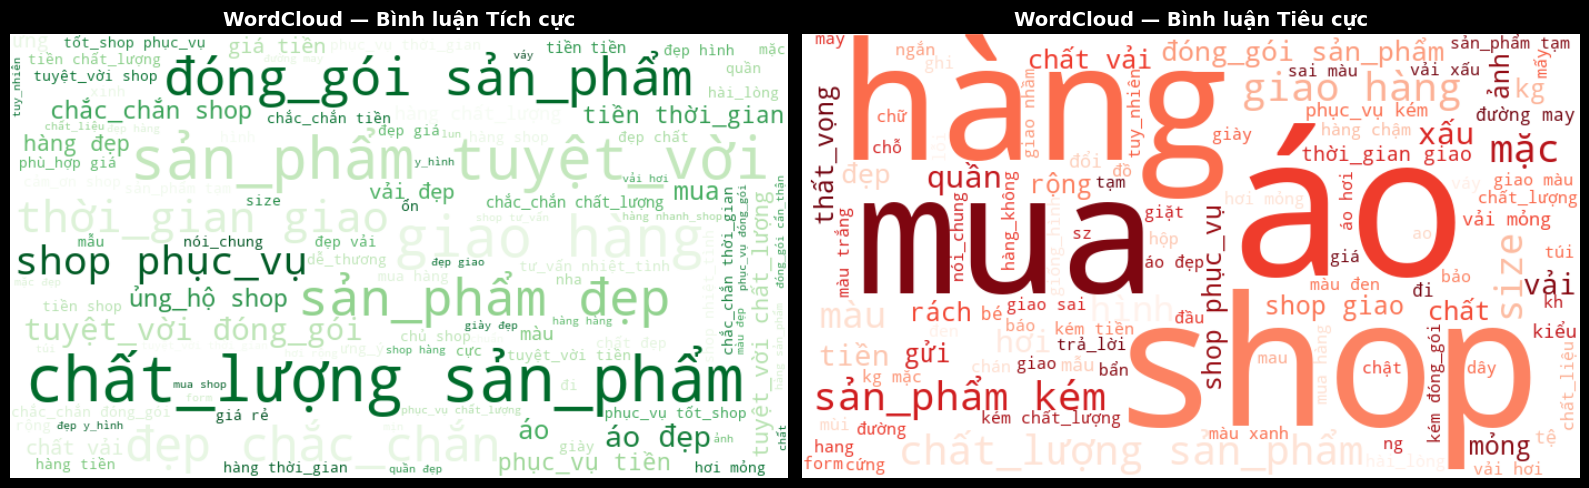

✅ WordCloud đã lưu tại datas/processed/wordcloud.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label_val, label_name, color) in enumerate([
    (1, 'Tích cực', 'Greens'),
    (0, 'Tiêu cực', 'Reds')
]):
    corpus = ' '.join(df[df['label'] == label_val]['processed_text'].dropna())
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=color,
        max_words=100,
        font_path=None,  # Đổi sang font tiếng Việt nếu có
    ).generate(corpus)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'WordCloud — Bình luận {label_name}',
                      fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ WordCloud đã lưu tại datas/processed/wordcloud.png')

## 8. Lưu kết quả

In [36]:
import scipy.sparse as sp

# Lưu dataset đã xử lý
df[['review_text', 'processed_text', 'label', 'source']].to_csv(
    PROCESSED_DIR / 'processed_reviews.csv',
    index=False, encoding='utf-8-sig'
)

# Lưu TF-IDF vectorizer
joblib.dump(tfidf, PROCESSED_DIR / 'tfidf_vectorizer.pkl')

# Lưu split data (sparse matrix)
sp.save_npz(str(PROCESSED_DIR / 'X_train.npz'), X_train)
sp.save_npz(str(PROCESSED_DIR / 'X_test.npz'), X_test)
np.save(str(PROCESSED_DIR / 'y_train.npy'), y_train)
np.save(str(PROCESSED_DIR / 'y_test.npy'), y_test)

print('✅ Phase 2 hoàn thành! Các file đã lưu:')
print(f'  - datas/processed/processed_reviews.csv')
print(f'  - datas/processed/tfidf_vectorizer.pkl')
print(f'  - datas/processed/X_train.npz, X_test.npz')
print(f'  - datas/processed/y_train.npy, y_test.npy')

✅ Phase 2 hoàn thành! Các file đã lưu:
  - datas/processed/processed_reviews.csv
  - datas/processed/tfidf_vectorizer.pkl
  - datas/processed/X_train.npz, X_test.npz
  - datas/processed/y_train.npy, y_test.npy
